# Ejercicios Prácticos - Actividad 8

## Algoritmo Deep Q-Network (DQN)

Reproducir el  ejemplo del juego Cartpole pero con uno de los siguientes juegos de Atari 2600:
1. Ms. Pacman
2. Space Invaders
3. Breakout
4. Enduro

En mi caso yo elegí Ms. Pacman, en el archivo configIsOrEs se encuentra ALE/MsPacman-v5

In [1]:
from DQNIsOrEs import is_atari_env, train_atari, train_cartpole
from plots import plot_training
from configIsOrEs import Config

En mi caso yo cuento con una GPU, por lo que la active por medio de torch para acelarar el entrenamiento, aproximadamente le tomo 35 minutos en realizar los 500,000 steps

[Atari] device: cuda
Ep 0001 | step=    515/500000 | R=  310.0 | avg20=  310.0 | eps=0.990 | replay=515
Ep 0002 | step=    965/500000 | R=  240.0 | avg20=  275.0 | eps=0.982 | replay=965
Ep 0003 | step=   1406/500000 | R=  210.0 | avg20=  253.3 | eps=0.973 | replay=1406
Ep 0004 | step=   1976/500000 | R=  280.0 | avg20=  260.0 | eps=0.962 | replay=1976
Ep 0005 | step=   2448/500000 | R=  200.0 | avg20=  248.0 | eps=0.953 | replay=2448
Ep 0006 | step=   2955/500000 | R=  230.0 | avg20=  245.0 | eps=0.944 | replay=2955
Ep 0007 | step=   3297/500000 | R=  140.0 | avg20=  230.0 | eps=0.937 | replay=3297
Ep 0008 | step=   3700/500000 | R=  240.0 | avg20=  231.2 | eps=0.930 | replay=3700
Ep 0009 | step=   4204/500000 | R=  250.0 | avg20=  233.3 | eps=0.920 | replay=4204
Ep 0010 | step=   4695/500000 | R=  270.0 | avg20=  237.0 | eps=0.911 | replay=4695
Ep 0011 | step=   5285/500000 | R=  280.0 | avg20=  240.9 | eps=0.900 | replay=5285
Ep 0012 | step=   5886/500000 | R=  430.0 | avg20=  256.7

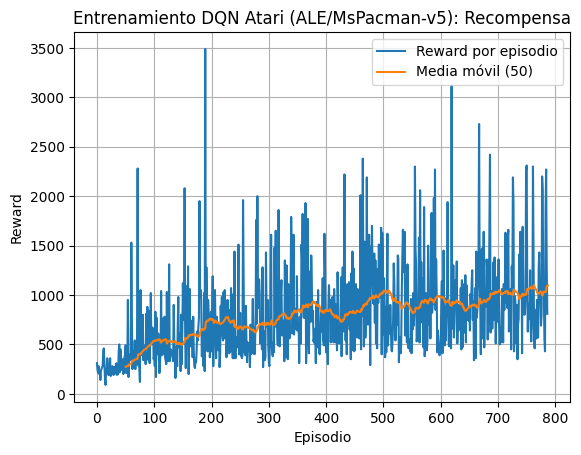

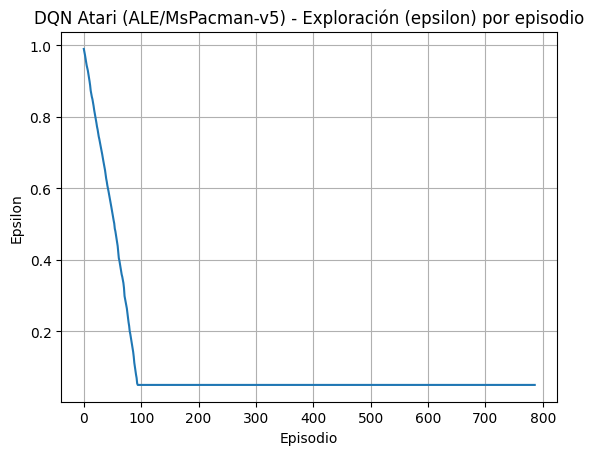

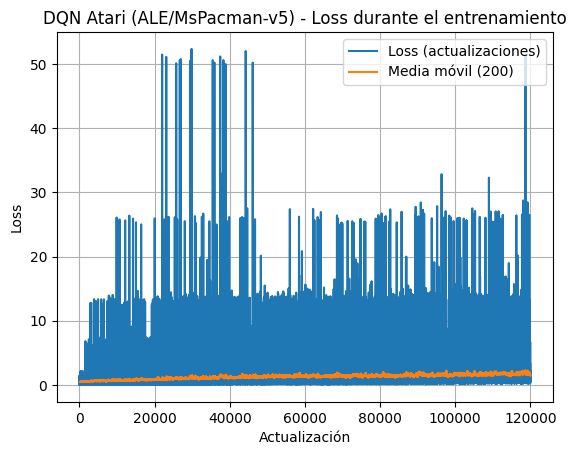

In [2]:
cfg = Config()

if is_atari_env(cfg.env_id):
    episode_rewards, episode_epsilons, losses = train_atari()
    plot_training(episode_rewards, episode_epsilons, losses, title_prefix=f"DQN Atari ({cfg.env_id})")
else:
    episode_rewards, episode_epsilons, losses = train_cartpole()
    plot_training(episode_rewards, episode_epsilons, losses, title_prefix=f"DQN ({cfg.env_id})")

Durante los primeros episodios se obtenian entre 100 y 400 puntos, conforme fue avanzando estos puntos fueron incrementando, a su vez el epsilon fue bajando poco a poco llegando al minimo que colocamos de .05, eso quiere decir que si logro explorar diferentes caminos. 

Vemos que llego alcanzar hasta 2000 puntos en algunos episodios, eso es bastante bueno, quiere decir que si fue aprendiendo algo.

Revise documentación en internet y dicen que para Ms. Pacman se necesitan alrededor de 5 millones a 50 millones de pasos para que el entrenamiento aprenda a jugar como un profesional. 

Nosotros solo utilizamos 500,000 pasos por lo que creo que 2000 puntos es un buen score para demostrar que si se logro aprender algo :) 

## Probando el resultado

Investigue como guardar el entrenamiento en un archivo para después verlo en acción, por lo que el entrenamiento se guarda en el archivo dqn_atari_model.pth y genere un archivo play.py para poner a jugar el entrenamiento hasta que termine.

In [ ]:
from play import play_game

play_game()

c:\Users\ismae\Documents\Diplomado IA\VSCode\SupervisedLearning\DQN\play.py:52: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("dqn_atari_mod

Para la SEMILLA 701 utilizada el intento con el entrenamiento llega a 1800 puntos aprox :) 